<a href="https://colab.research.google.com/github/sramponi86/Frigg_ETH_Hackaton_energy_prediction/blob/main/ramse_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Electricity Price Forecasting — DE-LU & ES

Two-regime forecasting system for Day-Ahead electricity prices.

**Short-term (≤ 7 days):** LightGBM quantile regression with weather forecasts, lagged prices, generation mix, and fuel prices.

**Long-term (> 7 days):** STL decomposition with linear trend extrapolation and volatility-scaled intervals.

The same feature vocabulary is used for both zones. DE-LU is wind-dominated with high cross-border interconnection. ES is solar-dominated and more isolated. The p50 model uses alpha=0.45 to match the competition's asymmetric pinball loss (q=0.45).

In [1]:
%pip install -q lightgbm pandas numpy requests statsmodels scikit-learn openmeteo-requests requests-cache retry-requests holidays matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.5/208.5 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.3/731.3 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 399.4/399.4 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 51.1 MB/s eta 0:00:00


## 1. Configuration

In [2]:
import os
import warnings
import requests
import requests_cache
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import holidays
import lightgbm as lgb
from statsmodels.tsa.seasonal import STL
from retry_requests import retry

warnings.filterwarnings('ignore')

# ENTSO-E token: register at https://transparency.entsoe.eu/usrm/user/createPublicUser
ENTSOE_TOKEN = os.getenv('ENTSOE_TOKEN', 'd1f67390-9b8c-426f-8197-d2cee651a779')

ZONES = {
    'DE-LU': {
        'entsoe_code': '10Y1001A1001A82H',
        'lat': 51.5,
        'lon': 10.0,
        'country': 'DE',
    },
    'ES': {
        'entsoe_code': '10YES-REE------0',
        'lat': 40.4,
        'lon': -3.7,
        'country': 'ES',
    },
}

# Evaluation window: 2026-05-08 18:00 to 2026-05-09 23:00 CEST (UTC+2)
EVAL_START = pd.Timestamp('2026-05-08T16:00:00', tz='UTC')
EVAL_END   = pd.Timestamp('2026-05-09T21:00:00', tz='UTC')

TRAIN_START = '2022-01-01'
TRAIN_END   = '2026-05-07'
WEATHER_END = (pd.Timestamp.utcnow() - pd.Timedelta(days=2)).strftime('%Y-%m-%d')

print(f'Evaluation window : {EVAL_START} -> {EVAL_END}')
print(f'Training period   : {TRAIN_START} to {TRAIN_END}')
print(f'Weather archive   : {TRAIN_START} to {WEATHER_END}')

Evaluation window : 2026-05-08 16:00:00+00:00 -> 2026-05-09 21:00:00+00:00
Training period   : 2022-01-01 to 2026-05-07
Weather archive   : 2022-01-01 to 2026-05-06


## 2. Data Loading

### 2a. ENTSO-E Prices

Source: https://transparency.entsoe.eu (document type A44).  
Alternative: export CSV from https://energy-charts.info and save as `data/{zone}_prices.csv`.

In [3]:
import xml.etree.ElementTree as ET

ENTSOE_BASE = 'https://web-api.tp.entsoe.eu/api'
NS = '{urn:iec62325.351:tc57wg16:451-3:publicationdocument:7:3}'


def _fetch_entsoe_single_chunk(zone_code, start, end):
    params = {
        'securityToken': ENTSOE_TOKEN,
        'documentType': 'A44',
        'in_Domain': zone_code,
        'out_Domain': zone_code,
        'periodStart': start.strftime('%Y%m%d%H00'),
        'periodEnd': end.strftime('%Y%m%d%H00'),
    }
    r = requests.get(ENTSOE_BASE, params=params, timeout=60)
    r.raise_for_status()
    root = ET.fromstring(r.text)
    err_ns = 'urn:iec62325.351:tc57wg16:451-1:acknowledgementdocument:7:0'
    reason = root.find(f'{{{err_ns}}}Reason/{{{err_ns}}}text')
    if reason is not None:
        raise ValueError(f'ENTSO-E error: {reason.text}')
    records = []
    for ts in root.findall(f'.//{NS}TimeSeries'):
        period = ts.find(f'{NS}Period')
        if period is None:
            continue
        t0 = pd.Timestamp(period.find(f'{NS}timeInterval/{NS}start').text)
        freq_min = int(period.find(f'{NS}resolution').text.replace('PT', '').replace('M', ''))
        for pt in period.findall(f'{NS}Point'):
            pos = int(pt.find(f'{NS}position').text)
            price = float(pt.find(f'{NS}price.amount').text)
            records.append({'timestamp': t0 + pd.Timedelta(minutes=freq_min * (pos - 1)), 'price': price})
    if not records:
        return pd.Series(dtype=float)
    return pd.DataFrame(records).drop_duplicates('timestamp').set_index('timestamp')['price'].sort_index()


def fetch_entsoe_prices(zone_code, start, end):
    """Fetch Day-Ahead prices in yearly chunks (API limit: P1Y per request)."""
    chunks = []
    chunk_start = start.normalize()
    while chunk_start < end:
        chunk_end = min(chunk_start + pd.DateOffset(years=1), end)
        print(f'  {zone_code}: {chunk_start.date()} to {chunk_end.date()}', end=' ... ')
        try:
            chunk = _fetch_entsoe_single_chunk(zone_code, chunk_start, chunk_end)
            print(f'{len(chunk)} records')
            if len(chunk) > 0:
                chunks.append(chunk)
        except Exception as e:
            print(f'skipped ({e})')
        chunk_start = chunk_end
    if not chunks:
        return pd.Series(dtype=float)
    combined = pd.concat(chunks)
    return combined[~combined.index.duplicated(keep='first')].sort_index()


def load_prices_from_csv(filepath):
    df = pd.read_csv(filepath, parse_dates=[0], index_col=0)
    df.index = pd.to_datetime(df.index, utc=True)
    return df.iloc[:, 0].rename('price')

### 2b. Gas and Carbon Prices

TTF gas (EUR/MWh) and ETS carbon (EUR/tonne) from monthly reference values (IEA, Ember, Eurostat).  
To use daily data, save `data/ttf_gas.csv` or `data/ets_carbon.csv` with columns `Date, Price` (e.g. from investing.com).

In [4]:
TTF_MONTHLY = {
    '2022-01': 73,  '2022-02': 83,  '2022-03': 121, '2022-04': 101,
    '2022-05': 91,  '2022-06': 104, '2022-07': 143, '2022-08': 199,
    '2022-09': 185, '2022-10': 113, '2022-11': 105, '2022-12': 80,
    '2023-01': 61,  '2023-02': 48,  '2023-03': 42,  '2023-04': 39,
    '2023-05': 31,  '2023-06': 32,  '2023-07': 30,  '2023-08': 34,
    '2023-09': 37,  '2023-10': 47,  '2023-11': 45,  '2023-12': 37,
    '2024-01': 28,  '2024-02': 24,  '2024-03': 25,  '2024-04': 28,
    '2024-05': 32,  '2024-06': 34,  '2024-07': 35,  '2024-08': 38,
    '2024-09': 37,  '2024-10': 39,  '2024-11': 43,  '2024-12': 45,
    '2025-01': 46,  '2025-02': 44,  '2025-03': 40,  '2025-04': 36,
    '2025-05': 33,  '2025-06': 34,  '2025-07': 36,  '2025-08': 38,
    '2025-09': 39,  '2025-10': 42,  '2025-11': 44,  '2025-12': 46,
    '2026-01': 44,  '2026-02': 41,  '2026-03': 38,  '2026-04': 35,
    '2026-05': 33,
}

ETS_MONTHLY = {
    '2022-01': 80,  '2022-02': 83,  '2022-03': 73,  '2022-04': 79,
    '2022-05': 84,  '2022-06': 75,  '2022-07': 79,  '2022-08': 92,
    '2022-09': 70,  '2022-10': 71,  '2022-11': 73,  '2022-12': 86,
    '2023-01': 84,  '2023-02': 96,  '2023-03': 90,  '2023-04': 88,
    '2023-05': 86,  '2023-06': 85,  '2023-07': 90,  '2023-08': 84,
    '2023-09': 83,  '2023-10': 75,  '2023-11': 67,  '2023-12': 65,
    '2024-01': 59,  '2024-02': 54,  '2024-03': 56,  '2024-04': 64,
    '2024-05': 67,  '2024-06': 65,  '2024-07': 67,  '2024-08': 65,
    '2024-09': 63,  '2024-10': 63,  '2024-11': 65,  '2024-12': 65,
    '2025-01': 62,  '2025-02': 60,  '2025-03': 64,  '2025-04': 63,
    '2025-05': 63,  '2025-06': 64,  '2025-07': 65,  '2025-08': 65,
    '2025-09': 64,  '2025-10': 64,  '2025-11': 65,  '2025-12': 65,
    '2026-01': 64,  '2026-02': 63,  '2026-03': 62,  '2026-04': 63,
    '2026-05': 63,
}


def _monthly_to_daily(monthly_dict, name):
    months = pd.date_range('2022-01-01', '2026-05-31', freq='MS', tz='UTC')
    vals = [monthly_dict.get(m.strftime('%Y-%m'), np.nan) for m in months]
    daily = pd.Series(vals, index=months, name=name).resample('D').interpolate('linear')
    rng = np.random.default_rng(42)
    return (daily + rng.normal(0, daily.std() * 0.03, len(daily))).clip(lower=1.0)


def fetch_ttf_gas_prices():
    csv_path = 'data/ttf_gas.csv'
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path, parse_dates=['Date'], index_col='Date')
        df.index = pd.to_datetime(df.index, utc=True)
        return df['Price'].rename('ttf_gas').sort_index()
    return _monthly_to_daily(TTF_MONTHLY, 'ttf_gas')


def fetch_ets_carbon_prices():
    csv_path = 'data/ets_carbon.csv'
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path, parse_dates=['Date'], index_col='Date')
        df.index = pd.to_datetime(df.index, utc=True)
        return df['Price'].rename('ets_carbon').sort_index()
    return _monthly_to_daily(ETS_MONTHLY, 'ets_carbon')


def align_daily_to_hourly(daily_series, hourly_index):
    return daily_series.reindex(hourly_index, method='ffill').ffill().bfill()


ttf_daily = fetch_ttf_gas_prices()
ets_daily = fetch_ets_carbon_prices()
print(f'TTF gas    : {ttf_daily.index.min().date()} to {ttf_daily.index.max().date()}, mean={ttf_daily.mean():.1f} EUR/MWh')
print(f'ETS carbon : {ets_daily.index.min().date()} to {ets_daily.index.max().date()}, mean={ets_daily.mean():.1f} EUR/tonne')

TTF gas    : 2022-01-01 to 2026-05-01, mean=55.9 EUR/MWh
ETS carbon : 2022-01-01 to 2026-05-01, mean=71.1 EUR/tonne


### 2c. Generation Mix (ENTSO-E A75)

Actual hourly generation by production type. Requires ENTSO-E token.  
Cached to `data/{zone}_generation.csv` after the first fetch.

In [5]:
PSR_TYPES = {
    'B01': 'biomass', 'B02': 'fossil_brown_coal', 'B04': 'fossil_gas',
    'B05': 'fossil_hard_coal', 'B06': 'fossil_oil', 'B09': 'geothermal',
    'B10': 'hydro_pumped', 'B11': 'hydro_run', 'B12': 'hydro_reservoir',
    'B14': 'nuclear', 'B15': 'other_renewable', 'B16': 'solar',
    'B17': 'waste', 'B18': 'wind_offshore', 'B19': 'wind_onshore', 'B20': 'other',
}

GEN_NS = '{urn:iec62325.351:tc57wg16:451-6:generationloaddocument:3:0}'


def _fetch_generation_chunk(zone_code, start, end):
    params = {
        'securityToken': ENTSOE_TOKEN,
        'documentType': 'A75',
        'processType': 'A16',
        'in_Domain': zone_code,
        'periodStart': start.strftime('%Y%m%d%H00'),
        'periodEnd': end.strftime('%Y%m%d%H00'),
    }
    r = requests.get(ENTSOE_BASE, params=params, timeout=60)
    r.raise_for_status()
    root = ET.fromstring(r.text)
    err_ns = 'urn:iec62325.351:tc57wg16:451-1:acknowledgementdocument:7:0'
    reason = root.find(f'{{{err_ns}}}Reason/{{{err_ns}}}text')
    if reason is not None:
        raise ValueError(f'ENTSO-E error: {reason.text}')
    records = {}
    for ts_elem in root.findall(f'.//{GEN_NS}TimeSeries'):
        psr = ts_elem.find(f'.//{GEN_NS}psrType')
        if psr is None:
            continue
        col_name = PSR_TYPES.get(psr.text, psr.text)
        period = ts_elem.find(f'{GEN_NS}Period')
        if period is None:
            continue
        t0 = pd.Timestamp(period.find(f'{GEN_NS}timeInterval/{GEN_NS}start').text)
        freq_min = int(period.find(f'{GEN_NS}resolution').text.replace('PT', '').replace('M', ''))
        for pt in period.findall(f'{GEN_NS}Point'):
            qty_elem = pt.find(f'{GEN_NS}quantity')
            if qty_elem is None:
                continue
            pos = int(pt.find(f'{GEN_NS}position').text)
            ts_val = t0 + pd.Timedelta(minutes=freq_min * (pos - 1))
            records.setdefault(ts_val, {})
            records[ts_val][col_name] = records[ts_val].get(col_name, 0) + float(qty_elem.text)
    if not records:
        return pd.DataFrame()
    df = pd.DataFrame.from_dict(records, orient='index').sort_index()
    df.index.name = 'timestamp'
    return df


def fetch_generation_mix(zone_code, zone_name):
    csv_path = f'data/{zone_name}_generation.csv'
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path, index_col=0, parse_dates=True)
        df.index = pd.to_datetime(df.index, utc=True)
        print(f'  [{zone_name}] Loaded generation mix: {df.shape}')
        return df
    if ENTSOE_TOKEN == 'YOUR_TOKEN_HERE':
        print(f'  [{zone_name}] No token, skipping generation mix')
        return pd.DataFrame()
    chunks = []
    chunk_start = pd.Timestamp(TRAIN_START, tz='UTC').normalize()
    end_ts = pd.Timestamp(WEATHER_END, tz='UTC')
    while chunk_start < end_ts:
        chunk_end = min(chunk_start + pd.DateOffset(years=1), end_ts)
        print(f'  [{zone_name}] {chunk_start.date()} to {chunk_end.date()}', end=' ... ')
        try:
            chunk = _fetch_generation_chunk(zone_code, chunk_start, chunk_end)
            print(f'{len(chunk)} rows')
            if len(chunk) > 0:
                chunks.append(chunk)
        except Exception as e:
            print(f'skipped ({e})')
        chunk_start = chunk_end
    if not chunks:
        return pd.DataFrame()
    gen = pd.concat(chunks)
    gen = gen[~gen.index.duplicated(keep='first')].sort_index().resample('1h').mean()
    os.makedirs('data', exist_ok=True)
    gen.to_csv(csv_path)
    print(f'  [{zone_name}] Saved to {csv_path}')
    return gen


gen_data = {}
for zone, cfg in ZONES.items():
    gen_data[zone] = fetch_generation_mix(cfg['entsoe_code'], zone)

  [DE-LU] 2022-01-01 to 2023-01-01 ... skipped (HTTPSConnectionPool(host='web-api.tp.entsoe.eu', port=443): Read timed out. (read timeout=60))
  [DE-LU] 2023-01-01 to 2024-01-01 ... skipped (HTTPSConnectionPool(host='web-api.tp.entsoe.eu', port=443): Read timed out. (read timeout=60))
  [DE-LU] 2024-01-01 to 2025-01-01 ... skipped (HTTPSConnectionPool(host='web-api.tp.entsoe.eu', port=443): Read timed out. (read timeout=60))
  [DE-LU] 2025-01-01 to 2026-01-01 ... skipped (HTTPSConnectionPool(host='web-api.tp.entsoe.eu', port=443): Read timed out. (read timeout=60))
  [DE-LU] 2026-01-01 to 2026-05-06 ... skipped (HTTPSConnectionPool(host='web-api.tp.entsoe.eu', port=443): Read timed out. (read timeout=60))
  [ES] 2022-01-01 to 2023-01-01 ... skipped (HTTPSConnectionPool(host='web-api.tp.entsoe.eu', port=443): Read timed out. (read timeout=60))
  [ES] 2023-01-01 to 2024-01-01 ... skipped (HTTPSConnectionPool(host='web-api.tp.entsoe.eu', port=443): Read timed out. (read timeout=60))
  [ES

### 2d. Weather (Open-Meteo ERA5)

Source: https://open-meteo.com — no API key required.  
Historical ERA5 reanalysis for training, 7-day forecast for the evaluation window.

In [6]:
import openmeteo_requests

cache_session = requests_cache.CachedSession('.weather_cache', expire_after=3600)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

WEATHER_VARS = [
    'temperature_2m',
    'wind_speed_10m',
    'wind_speed_100m',
    'shortwave_radiation',
    'direct_radiation',
    'cloud_cover',
]


def _parse_openmeteo_response(resp):
    hourly = resp.Hourly()
    times = pd.date_range(
        start=pd.to_datetime(hourly.Time(), unit='s', utc=True),
        end=pd.to_datetime(hourly.TimeEnd(), unit='s', utc=True),
        freq=pd.Timedelta(seconds=hourly.Interval()),
        inclusive='left'
    )
    df = pd.DataFrame(index=times)
    for i, var in enumerate(WEATHER_VARS):
        df[var] = hourly.Variables(i).ValuesAsNumpy()
    return df


def fetch_weather_historical(lat, lon, start, end):
    url = 'https://archive-api.open-meteo.com/v1/archive'
    params = {'latitude': lat, 'longitude': lon, 'start_date': start, 'end_date': end,
              'hourly': WEATHER_VARS, 'timezone': 'UTC', 'wind_speed_unit': 'ms'}
    return _parse_openmeteo_response(openmeteo.weather_api(url, params=params)[0])


def fetch_weather_forecast(lat, lon):
    url = 'https://api.open-meteo.com/v1/forecast'
    params = {'latitude': lat, 'longitude': lon, 'hourly': WEATHER_VARS,
              'timezone': 'UTC', 'wind_speed_unit': 'ms', 'forecast_days': 7}
    return _parse_openmeteo_response(openmeteo.weather_api(url, params=params)[0])

### 2e. Assemble Training Data

In [7]:
def build_zone_dataset(zone_name, cfg):
    print(f'\nBuilding dataset: {zone_name}')

    price_csv = f'data/{zone_name}_prices.csv'
    if os.path.exists(price_csv):
        prices = load_prices_from_csv(price_csv)
        print(f'  Prices: {len(prices)} rows (CSV)')
    elif ENTSOE_TOKEN != 'YOUR_TOKEN_HERE':
        prices = fetch_entsoe_prices(
            cfg['entsoe_code'],
            pd.Timestamp(TRAIN_START, tz='UTC'),
            pd.Timestamp(TRAIN_END, tz='UTC')
        )
        print(f'  Prices: {len(prices)} rows (API)')
    else:
        raise FileNotFoundError(
            f'No price data for {zone_name}. Provide {price_csv} or set ENTSOE_TOKEN.'
        )

    prices = prices.resample('1h').mean()

    weather_csv = f'data/{zone_name}_weather.csv'
    if os.path.exists(weather_csv):
        weather = pd.read_csv(weather_csv, index_col=0, parse_dates=True)
        weather.index = pd.to_datetime(weather.index, utc=True)
        print(f'  Weather: {len(weather)} rows (CSV)')
    else:
        print(f'  Fetching weather (end: {WEATHER_END})')
        chunks = []
        for yr_start in pd.date_range(TRAIN_START, WEATHER_END, freq='YS'):
            yr_end = min(yr_start + pd.DateOffset(years=1) - pd.Timedelta(days=1), pd.Timestamp(WEATHER_END))
            print(f'    {yr_start.date()} to {yr_end.date()}')
            chunks.append(fetch_weather_historical(cfg['lat'], cfg['lon'],
                                                   yr_start.strftime('%Y-%m-%d'),
                                                   yr_end.strftime('%Y-%m-%d')))
        weather = pd.concat(chunks)
        os.makedirs('data', exist_ok=True)
        weather.to_csv(weather_csv)
        print(f'  Weather: {len(weather)} rows (saved)')

    df = pd.DataFrame({'price': prices}).join(weather, how='left')
    df['ttf_gas']    = align_daily_to_hourly(ttf_daily, df.index)
    df['ets_carbon'] = align_daily_to_hourly(ets_daily, df.index)

    if zone_name in gen_data and len(gen_data[zone_name]) > 0:
        gen = gen_data[zone_name].copy()
        gen.index = pd.to_datetime(gen.index, utc=True)
        gen = gen.reindex(df.index, method='nearest', tolerance=pd.Timedelta('90min'))
        gen.columns = [f'gen_{c}' for c in gen.columns]
        df = df.join(gen, how='left')
        print(f'  Generation mix: {len(gen.columns)} columns')

    print(f'  Final shape: {df.shape}')
    return df


raw_data = {}
for zone, cfg in ZONES.items():
    raw_data[zone] = build_zone_dataset(zone, cfg)


Building dataset: DE-LU
  10Y1001A1001A82H: 2022-01-01 to 2023-01-01 ... skipped (HTTPSConnectionPool(host='web-api.tp.entsoe.eu', port=443): Read timed out. (read timeout=60))
  10Y1001A1001A82H: 2023-01-01 to 2024-01-01 ... 34711 records
  10Y1001A1001A82H: 2024-01-01 to 2025-01-01 ... 35064 records
  10Y1001A1001A82H: 2025-01-01 to 2026-01-01 ... 34935 records
  10Y1001A1001A82H: 2026-01-01 to 2026-05-07 ... 12171 records
  Prices: 116602 rows (API)
  Fetching weather (end: 2026-05-06)
    2022-01-01 to 2022-12-31
    2023-01-01 to 2023-12-31
    2024-01-01 to 2024-12-31
    2025-01-01 to 2025-12-31
    2026-01-01 to 2026-05-06
  Weather: 38088 rows (saved)
  Final shape: (29351, 9)

Building dataset: ES
  10YES-REE------0: 2022-01-01 to 2023-01-01 ... 8440 records
  10YES-REE------0: 2023-01-01 to 2024-01-01 ... 8249 records
  10YES-REE------0: 2024-01-01 to 2025-01-01 ... 7951 records
  10YES-REE------0: 2025-01-01 to 2026-01-01 ... 16837 records
  10YES-REE------0: 2026-01-01 to

## 3. Feature Engineering

In [8]:
def make_features(df, country):
    out = df.copy()
    idx = out.index

    out['hour']       = idx.hour
    out['dow']        = idx.dayofweek
    out['month']      = idx.month
    out['doy']        = idx.dayofyear
    out['week']       = idx.isocalendar().week.astype(int)
    out['is_weekend'] = (idx.dayofweek >= 5).astype(int)

    out['hour_sin'] = np.sin(2 * np.pi * idx.hour / 24)
    out['hour_cos'] = np.cos(2 * np.pi * idx.hour / 24)
    out['doy_sin']  = np.sin(2 * np.pi * idx.dayofyear / 365.25)
    out['doy_cos']  = np.cos(2 * np.pi * idx.dayofyear / 365.25)
    out['dow_sin']  = np.sin(2 * np.pi * idx.dayofweek / 7)
    out['dow_cos']  = np.cos(2 * np.pi * idx.dayofweek / 7)

    country_holidays = holidays.country_holidays(country)
    out['is_holiday']      = idx.normalize().map(lambda d: int(d in country_holidays))
    out['is_pre_holiday']  = out['is_holiday'].shift(-24, fill_value=0)
    out['is_post_holiday'] = out['is_holiday'].shift(24, fill_value=0)

    for lag in [1, 2, 3, 6, 12, 24, 48, 168]:
        out[f'price_lag_{lag}h'] = out['price'].shift(lag)

    for window in [24, 168]:
        out[f'price_roll_mean_{window}h'] = out['price'].shift(1).rolling(window).mean()
        out[f'price_roll_std_{window}h']  = out['price'].shift(1).rolling(window).std()
        out[f'price_roll_min_{window}h']  = out['price'].shift(1).rolling(window).min()
        out[f'price_roll_max_{window}h']  = out['price'].shift(1).rolling(window).max()

    out['price_same_hour_yesterday'] = out['price'].shift(24)
    out['price_same_hour_lastweek']  = out['price'].shift(168)
    out['price_7d_vs_30d'] = (
        out['price'].shift(1).rolling(168).mean() /
        (out['price'].shift(1).rolling(720).mean() + 1e-9)
    )

    if 'wind_speed_100m' in out.columns:
        out['wind_power_proxy'] = np.clip(out['wind_speed_100m'] ** 3, 0, 1000)

    if 'shortwave_radiation' in out.columns:
        out['solar_proxy']   = out['shortwave_radiation'].clip(lower=0)
        out['solar_roll_3h'] = out['solar_proxy'].rolling(3, center=True, min_periods=1).mean()

    if 'temperature_2m' in out.columns:
        out['HDD']     = np.maximum(0, 15 - out['temperature_2m'])
        out['CDD']     = np.maximum(0, out['temperature_2m'] - 22)
        out['temp_sq'] = out['temperature_2m'] ** 2

    if 'ttf_gas' in out.columns:
        out['ttf_gas_lag1d']  = out['ttf_gas'].shift(24)
        out['ttf_gas_roll7d'] = out['ttf_gas'].shift(24).rolling(168).mean()
        out['ttf_gas_mom']    = out['ttf_gas'] / (out['ttf_gas'].shift(168) + 1e-9)

    if 'ets_carbon' in out.columns:
        out['ets_carbon_lag1d']  = out['ets_carbon'].shift(24)
        out['ets_carbon_roll7d'] = out['ets_carbon'].shift(24).rolling(168).mean()
        if 'ttf_gas' in out.columns:
            out['implied_gas_carbon_cost'] = out['ttf_gas'] / 0.45 + out['ets_carbon'] * 0.2 / 0.45

    gen_cols = [c for c in out.columns if c.startswith('gen_')]
    if gen_cols:
        renewable_cols = [c for c in gen_cols if any(x in c for x in ['wind', 'solar', 'hydro_run', 'biomass', 'geothermal'])]
        fossil_cols    = [c for c in gen_cols if any(x in c for x in ['fossil', 'nuclear'])]
        if renewable_cols:
            out['total_renewables_mw'] = out[renewable_cols].sum(axis=1)
            out['renewables_lag24h']   = out['total_renewables_mw'].shift(24)
            out['renewables_lag168h']  = out['total_renewables_mw'].shift(168)
        if fossil_cols:
            out['total_fossil_nuclear_mw'] = out[fossil_cols].sum(axis=1)
        if renewable_cols and fossil_cols:
            out['renewable_share'] = out['total_renewables_mw'] / (out['total_renewables_mw'] + out['total_fossil_nuclear_mw'] + 1e-9)
        if 'gen_nuclear' in out.columns:
            out['nuclear_lag24h'] = out['gen_nuclear'].shift(24)
        if 'gen_hydro_reservoir' in out.columns:
            out['hydro_reservoir_lag24h'] = out['gen_hydro_reservoir'].shift(24)
            out['hydro_reservoir_roll7d'] = out['gen_hydro_reservoir'].shift(24).rolling(168).mean()

    return out


feat_data = {}
for zone, cfg in ZONES.items():
    feat_data[zone] = make_features(raw_data[zone], cfg['country'])
    print(f'{zone}: {feat_data[zone].shape[1]} features')

DE-LU: 55 features
ES: 55 features


## 4. Exploratory Data Analysis

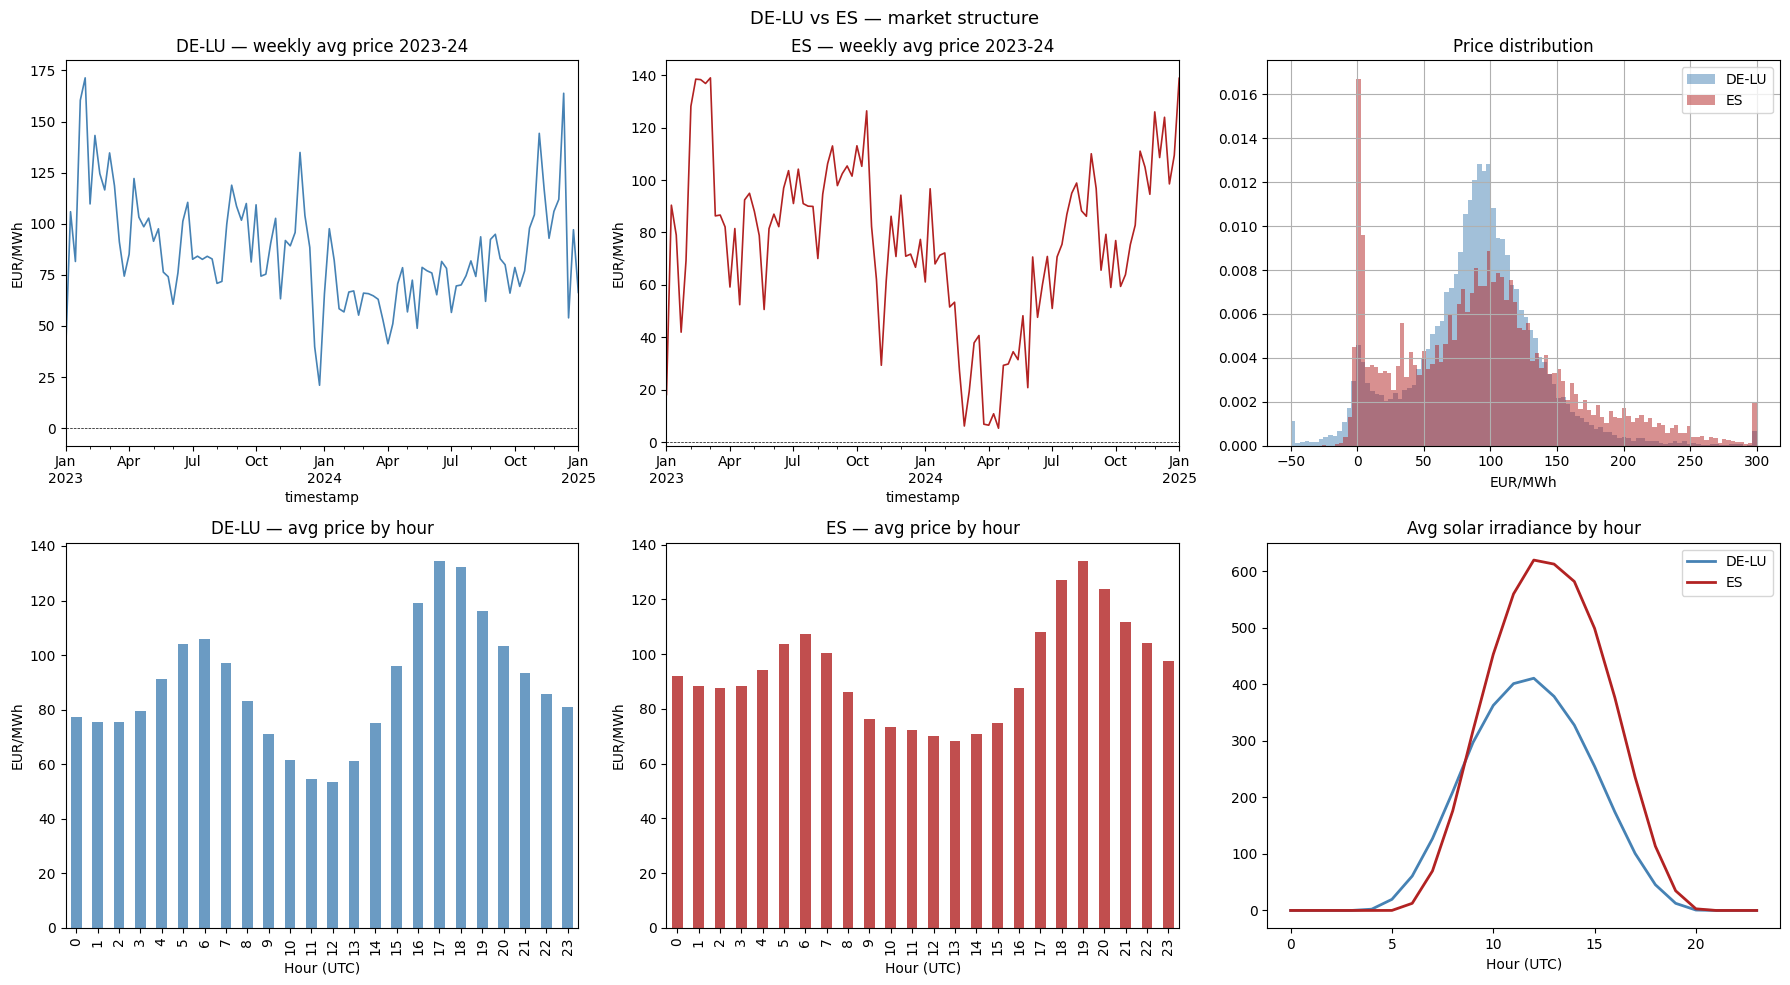

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('DE-LU vs ES — market structure', fontsize=13)

for col, zone in enumerate(ZONES):
    df = feat_data[zone].dropna(subset=['price'])
    color = 'steelblue' if zone == 'DE-LU' else 'firebrick'

    ax = axes[0, col]
    df['2023':'2024']['price'].resample('W').mean().plot(ax=ax, color=color, linewidth=1.2)
    ax.set_title(f'{zone} — weekly avg price 2023-24')
    ax.set_ylabel('EUR/MWh')
    ax.axhline(0, color='k', linestyle='--', linewidth=0.5)

    ax2 = axes[1, col]
    df.groupby('hour')['price'].mean().plot(kind='bar', ax=ax2, color=color, alpha=0.8)
    ax2.set_title(f'{zone} — avg price by hour')
    ax2.set_xlabel('Hour (UTC)')
    ax2.set_ylabel('EUR/MWh')

ax3 = axes[0, 2]
for zone, color in [('DE-LU', 'steelblue'), ('ES', 'firebrick')]:
    feat_data[zone]['price'].dropna().clip(-50, 300).hist(
        bins=100, alpha=0.5, color=color, label=zone, density=True, ax=ax3)
ax3.set_title('Price distribution')
ax3.set_xlabel('EUR/MWh')
ax3.legend()

ax4 = axes[1, 2]
for zone, color in [('DE-LU', 'steelblue'), ('ES', 'firebrick')]:
    if 'solar_proxy' in feat_data[zone].columns:
        feat_data[zone].groupby('hour')['solar_proxy'].mean().plot(ax=ax4, color=color, label=zone, linewidth=2)
ax4.set_title('Avg solar irradiance by hour')
ax4.set_xlabel('Hour (UTC)')
ax4.legend()

plt.tight_layout()
plt.savefig('eda_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Model Training

Three LightGBM quantile models per zone: p2.5, p50, p97.5.  
p50 uses alpha=0.45 to match the competition pinball loss (q=0.45).

In [10]:
NON_FEATURES = {'price'}


def get_feature_cols(df):
    return [c for c in df.columns if c not in NON_FEATURES]


def pinball_loss(y_true, y_pred, q=0.45):
    r = np.asarray(y_true) - np.asarray(y_pred)
    return float(np.mean(np.where(r >= 0, q * r, (q - 1) * r)))


def train_zone_models(zone, df):
    print(f'\nTraining: {zone}')
    df_clean = df.dropna(subset=['price']).dropna(thresh=int(len(df.columns) * 0.7))
    feature_cols = get_feature_cols(df_clean)
    X, y = df_clean[feature_cols], df_clean['price']

    cutoff = df_clean.index.max() - pd.DateOffset(months=3)
    X_train, y_train = X[X.index < cutoff], y[y.index < cutoff]
    X_val,   y_val   = X[X.index >= cutoff], y[y.index >= cutoff]
    print(f'  Train: {len(X_train)}  Val: {len(X_val)}')

    base_params = {
        'boosting_type': 'gbdt', 'n_estimators': 1500, 'learning_rate': 0.03,
        'num_leaves': 63, 'max_depth': 8, 'min_child_samples': 30,
        'subsample': 0.8, 'colsample_bytree': 0.8,
        'reg_alpha': 0.1, 'reg_lambda': 1.0,
        'n_jobs': -1, 'verbose': -1, 'random_state': 42,
    }

    quantiles = {'p025': 0.025, 'p50': 0.45, 'p975': 0.975}
    callbacks = [lgb.early_stopping(50, verbose=False), lgb.log_evaluation(period=-1)]
    models = {}

    for name, alpha in quantiles.items():
        model = lgb.LGBMRegressor(**{**base_params, 'objective': 'quantile', 'alpha': alpha})
        model.fit(X_train, y_train, eval_set=[(X_val, y_val)], callbacks=callbacks)
        models[name] = model
        pl = pinball_loss(y_val, model.predict(X_val), q=0.45)
        print(f'  {name} alpha={alpha:.3f} | pinball={pl:.4f} | iters={model.best_iteration_}')

    return models, feature_cols


all_models = {}
all_feature_cols = {}
for zone in ZONES:
    m, fcols = train_zone_models(zone, feat_data[zone])
    all_models[zone] = m
    all_feature_cols[zone] = fcols


Training: DE-LU
  Train: 27190  Val: 2137
  p025 alpha=0.025 | pinball=8.0196 | iters=545
  p50 alpha=0.450 | pinball=3.8990 | iters=1499
  p975 alpha=0.975 | pinball=10.0509 | iters=320

Training: ES
  Train: 33847  Val: 2135
  p025 alpha=0.025 | pinball=6.0833 | iters=445
  p50 alpha=0.450 | pinball=2.9417 | iters=776
  p975 alpha=0.975 | pinball=8.0390 | iters=465


## 6. Feature Importance Comparison

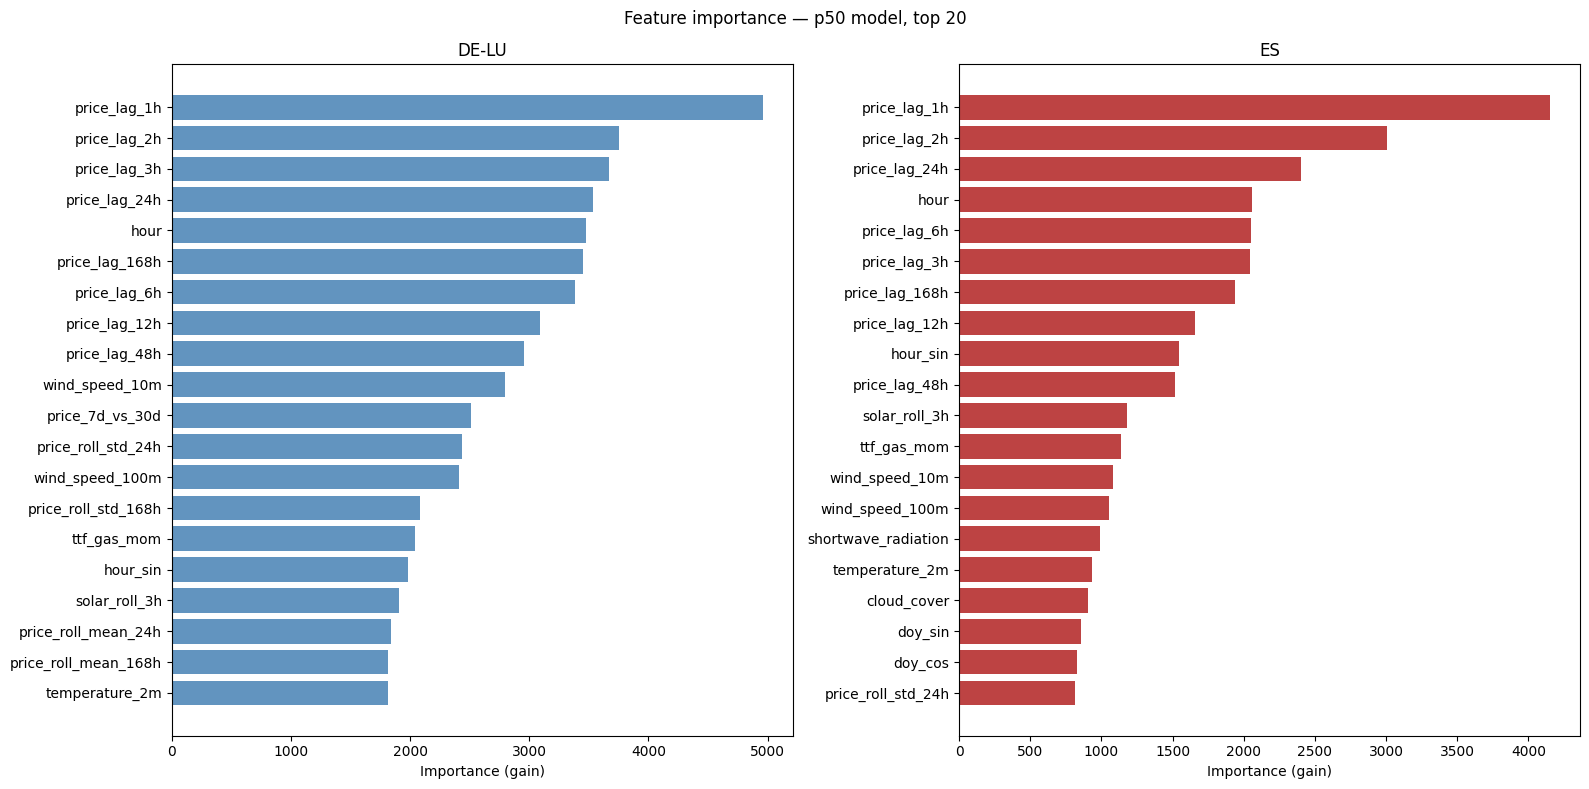

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('Feature importance — p50 model, top 20', fontsize=12)

for ax, zone in zip(axes, ZONES):
    fi = pd.Series(all_models[zone]['p50'].feature_importances_, index=all_feature_cols[zone])
    top = fi.nlargest(20).sort_values()
    color = 'steelblue' if zone == 'DE-LU' else 'firebrick'
    ax.barh(top.index, top.values, color=color, alpha=0.85)
    ax.set_title(zone)
    ax.set_xlabel('Importance (gain)')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Forecasting Engine

Short-term (≤ 7 days): LightGBM with Open-Meteo forecast weather.  
Long-term (> 7 days): STL decomposition + linear trend + volatility-scaled intervals.

In [12]:
def _climatological_weather(hist, target_idx):
    weather_cols = [c for c in hist.columns if c in WEATHER_VARS]
    result = pd.DataFrame(index=target_idx, columns=weather_cols, dtype=float)
    for ts in target_idx:
        mask = (hist.index.month == ts.month) & (hist.index.day == ts.day) & (hist.index.hour == ts.hour)
        result.loc[ts, weather_cols] = hist.loc[mask, weather_cols].mean()
    return result


def build_forecast_features(zone, cfg, start, end, historical_df):
    horizon_index = pd.date_range(start, end, freq='1h', tz='UTC')
    df_fcst = pd.DataFrame(index=horizon_index)
    df_fcst['price'] = np.nan

    days_ahead = (start - pd.Timestamp.now(tz='UTC')).days
    weather_fcst = (fetch_weather_forecast(cfg['lat'], cfg['lon'])
                    if days_ahead <= 6
                    else _climatological_weather(historical_df, horizon_index))

    df_fcst = df_fcst.join(weather_fcst.reindex(horizon_index, method='nearest'), how='left')
    combined = pd.concat([historical_df, df_fcst])
    combined = combined[~combined.index.duplicated(keep='last')].sort_index()
    return make_features(combined, cfg['country']).loc[horizon_index]


def longterm_forecast_stl(zone, historical_prices, horizon_index):
    hist = historical_prices.dropna().last('730D').resample('1h').mean().ffill()
    daily = hist.resample('D').mean().ffill()
    result = STL(daily, period=7, robust=True).fit()

    slope, intercept = np.polyfit(np.arange(len(result.trend)), result.trend.values, 1)
    seasonal_profile = hist.groupby([hist.index.month, hist.index.hour]).mean()
    overall_mean = hist.mean()
    hist_vol = daily.std()
    n_hist_days = len(daily)

    records = []
    for ts in horizon_index:
        days_out = (ts - hist.index[-1]).days
        trend_val = intercept + slope * (n_hist_days + days_out)
        try:
            seas_adj = seasonal_profile.get((ts.month, ts.hour), overall_mean) - overall_mean
        except Exception:
            seas_adj = 0
        p50 = trend_val + seas_adj
        uncertainty = 1.96 * hist_vol * np.sqrt(max(1, days_out) / 30)
        records.append({'timestamp': ts, 'p025': p50 - uncertainty, 'p50': p50, 'p975': p50 + uncertainty})

    return pd.DataFrame(records).set_index('timestamp')


def predict_zone(zone, cfg, start, end, historical_df, models, feature_cols, short_term_days=7):
    now = pd.Timestamp.now(tz='UTC')
    horizon_index = pd.date_range(start, end, freq='1h', tz='UTC')
    short_cutoff = now + pd.Timedelta(days=short_term_days)
    short_idx = horizon_index[horizon_index <= short_cutoff]
    long_idx  = horizon_index[horizon_index >  short_cutoff]

    results = []

    if len(short_idx) > 0:
        print(f'  [{zone}] Short-term: {len(short_idx)} hours')
        X_fcst = build_forecast_features(zone, cfg, short_idx[0], short_idx[-1], historical_df)
        for col in feature_cols:
            if col not in X_fcst.columns:
                X_fcst[col] = 0.0
        X_fcst = X_fcst[feature_cols].ffill().fillna(0)
        for ts in short_idx:
            row = X_fcst.loc[[ts]] if ts in X_fcst.index else X_fcst.iloc[[-1]]
            results.append({
                'timestamp': ts,
                'p025': float(models['p025'].predict(row)[0]),
                'p50':  float(models['p50'].predict(row)[0]),
                'p975': float(models['p975'].predict(row)[0]),
                'regime': 'short_term',
            })

    if len(long_idx) > 0:
        print(f'  [{zone}] Long-term: {len(long_idx)} hours')
        lt = longterm_forecast_stl(zone, historical_df['price'], long_idx)
        for ts in long_idx:
            row = lt.loc[ts] if ts in lt.index else lt.iloc[-1]
            results.append({
                'timestamp': ts,
                'p025': float(row['p025']),
                'p50':  float(row['p50']),
                'p975': float(row['p975']),
                'regime': 'long_term',
            })

    df_out = pd.DataFrame(results).set_index('timestamp').sort_index()
    df_out['p025'] = np.minimum(df_out['p025'], df_out['p50'])
    df_out['p975'] = np.maximum(df_out['p975'], df_out['p50'])
    return df_out

## 8. Long-term Forecast (2 years)

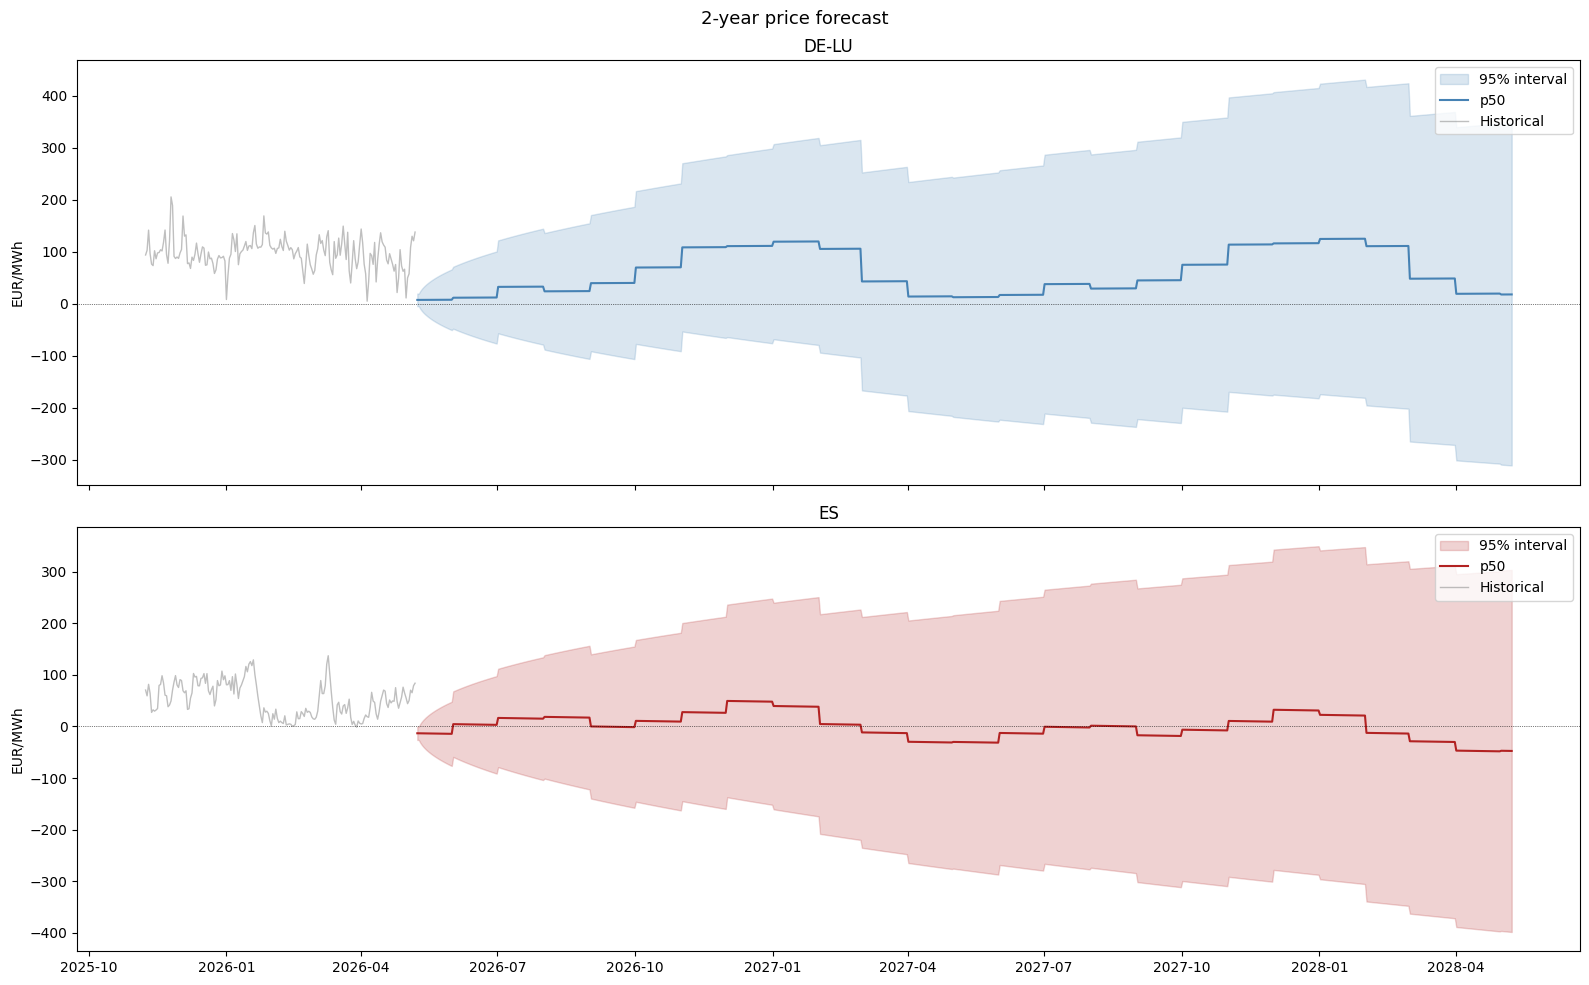

In [13]:
lt_start = pd.Timestamp.now(tz='UTC').ceil('1h')
lt_end   = lt_start + pd.DateOffset(years=2)
lt_idx   = pd.date_range(lt_start, lt_end, freq='D', tz='UTC')

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
fig.suptitle('2-year price forecast', fontsize=13)

for ax, zone in zip(axes, ZONES):
    color = 'steelblue' if zone == 'DE-LU' else 'firebrick'
    lt_pred = longterm_forecast_stl(zone, feat_data[zone]['price'], lt_idx)
    hist = feat_data[zone]['price'].last('180D').resample('D').mean()

    ax.fill_between(lt_pred.index, lt_pred['p025'], lt_pred['p975'], alpha=0.2, color=color, label='95% interval')
    ax.plot(lt_pred.index, lt_pred['p50'], color=color, linewidth=1.5, label='p50')
    ax.plot(hist.index, hist.values, color='gray', linewidth=1, alpha=0.5, label='Historical')
    ax.set_title(zone)
    ax.set_ylabel('EUR/MWh')
    ax.legend(loc='upper right')
    ax.axhline(0, color='k', linestyle=':', linewidth=0.5)

plt.tight_layout()
plt.savefig('longterm_forecast.png', dpi=120, bbox_inches='tight')
plt.show()

## 9. Evaluation Window Predictions

In [14]:
print(f'Evaluation window: {EVAL_START} to {EVAL_END}')

eval_preds = {}
for zone in ZONES:
    eval_preds[zone] = predict_zone(
        zone=zone, cfg=ZONES[zone],
        start=EVAL_START, end=EVAL_END,
        historical_df=feat_data[zone],
        models=all_models[zone],
        feature_cols=all_feature_cols[zone],
        short_term_days=7,
    )
    print(f'  {zone}: {len(eval_preds[zone])} rows')

Evaluation window: 2026-05-08 16:00:00+00:00 to 2026-05-09 21:00:00+00:00
  [DE-LU] Short-term: 30 hours
  DE-LU: 30 rows
  [ES] Short-term: 30 hours
  ES: 30 rows


In [15]:
TEAM_NAME = 'ramse'

eval_timestamps_utc = pd.date_range(EVAL_START, EVAL_END, freq='1h', tz='UTC')
assert len(eval_timestamps_utc) == 30

rows = []
for ts_utc in eval_timestamps_utc:
    ts_str = ts_utc.tz_convert('Europe/Berlin').isoformat()
    de = eval_preds['DE-LU'].loc[ts_utc] if ts_utc in eval_preds['DE-LU'].index else eval_preds['DE-LU'].iloc[-1]
    es = eval_preds['ES'].loc[ts_utc]    if ts_utc in eval_preds['ES'].index    else eval_preds['ES'].iloc[-1]
    rows.append({
        'timestamp':   ts_str,
        'DE-LU p025':  round(float(de['p025']), 2),
        'DE-LU p50':   round(float(de['p50']),  2),
        'DE-LU p975':  round(float(de['p975']), 2),
        'ES p025':     round(float(es['p025']), 2),
        'ES p50':      round(float(es['p50']),  2),
        'ES p975':     round(float(es['p975']), 2),
    })

submission = pd.DataFrame(rows)
assert len(submission) == 30
assert list(submission.columns) == ['timestamp', 'DE-LU p025', 'DE-LU p50', 'DE-LU p975', 'ES p025', 'ES p50', 'ES p975']
assert submission.isnull().sum().sum() == 0

fname = f'{TEAM_NAME}_predictions.csv'
submission.to_csv(fname, index=False)
print(f'Saved: {fname} ({len(submission)} rows)')
submission.head()

Saved: ramse_predictions.csv (30 rows)


,timestamp,DE-LU p025,DE-LU p50,DE-LU p975,ES p025,ES p50,ES p975
0,2026-05-08T18:00:00+02:00,121.13,138.77,154.43,113.07,125.39,144.66
1,2026-05-08T19:00:00+02:00,121.08,137.72,145.43,118.93,134.64,164.76
2,2026-05-08T20:00:00+02:00,120.15,129.24,142.66,120.70,136.31,168.83
3,2026-05-08T21:00:00+02:00,115.04,117.07,136.24,120.23,133.99,166.06
4,2026-05-08T22:00:00+02:00,114.70,117.17,135.71,106.91,119.22,134.08


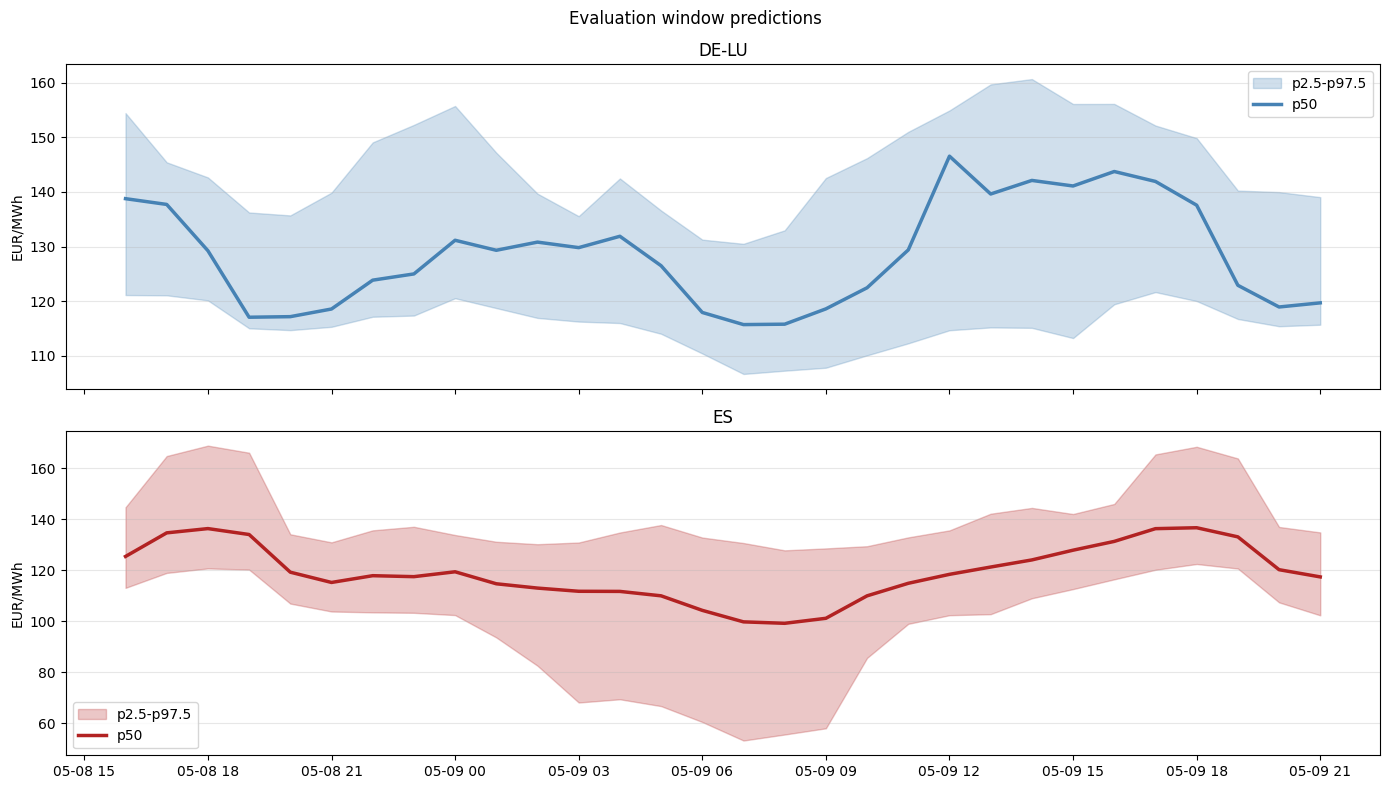

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle('Evaluation window predictions', fontsize=12)

for ax, zone, color in zip(axes, ['DE-LU', 'ES'], ['steelblue', 'firebrick']):
    p = eval_preds[zone]
    ax.fill_between(p.index, p['p025'], p['p975'], alpha=0.25, color=color, label='p2.5-p97.5')
    ax.plot(p.index, p['p50'], color=color, linewidth=2.5, label='p50')
    ax.set_title(zone)
    ax.set_ylabel('EUR/MWh')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('eval_predictions.png', dpi=120, bbox_inches='tight')
plt.show()

## 10. Data README

In [17]:
readme = """Data README

DE-LU_prices.csv / ES_prices.csv
  Source    : ENTSO-E Transparency Platform / energy-charts.info
  Variables : timestamp (UTC), price (EUR/MWh)
  Frequency : hourly
  Period    : 2022-01-01 to 2026-05-07
  Zones     : DE-LU (EIC 10Y1001A1001A82H), ES (EIC 10YES-REE------0)

DE-LU_weather.csv / ES_weather.csv
  Source    : Open-Meteo ERA5 reanalysis (https://open-meteo.com)
  Variables : temperature_2m, wind_speed_10m, wind_speed_100m,
              shortwave_radiation, direct_radiation, cloud_cover
  Frequency : hourly UTC
  Period    : 2022-01-01 to ~2 days before run date
  Coords    : DE-LU (51.5, 10.0), ES (40.4, -3.7)

DE-LU_generation.csv / ES_generation.csv
  Source    : ENTSO-E A75 (Actual Generation per Production Type)
  Variables : per-fuel MWh columns (wind, solar, nuclear, gas, hydro, etc.)
  Frequency : hourly UTC
  Period    : 2022-01-01 to ~2 days before run date

TTF gas and ETS carbon prices are interpolated from monthly reference values
(IEA Gas Market Report, Ember European Power Sector Review, Eurostat).
Place data/ttf_gas.csv or data/ets_carbon.csv (columns: Date, Price)
to use higher-resolution daily data from investing.com.
"""

os.makedirs('data', exist_ok=True)
with open('data/README.txt', 'w') as f:
    f.write(readme)
print('data/README.txt written')

data/README.txt written
